<a href="https://colab.research.google.com/github/xDanilog27/Bussiness-Inteligent/blob/main/Proyecto_Final_Final_(20_)_%E2%80%93_Anal%C3%ADtica_de_Negocios_Danilo_Garcia_Hoyos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introducción**

En el marco del curso de Analítica de Negocios, se llevó a cabo un análisis enfocado en el fenómeno creciente de la adicción a redes sociales en estudiantes. El objetivo principal fue predecir el nivel de adicción y comprender qué variables personales, académicas y conductuales están más asociadas con este comportamiento.

Para este propósito, se empleó el conjunto de datos titulado “Student Social Media & Relationships”, obtenido de Kaggle. Esta base ofrece un panorama representativo y diverso, con información de estudiantes de distintos países y niveles académicos, recolectada mediante encuestas validadas en el primer trimestre de 2025. Se trata de un dataset adecuado para tareas de análisis estadístico, modelado predictivo y agrupamiento.

Contexto de la Base de Datos

Población objetivo: Estudiantes de entre 16 y 25 años.
Ámbito geográfico: Multipaís (Bangladesh, India, USA, UK, Canadá, Australia, Alemania, Brasil, Japón, Corea del Sur).
Fuente de recolección: Encuesta anónima aplicada en línea.
Escalas utilizadas: Bergen Social Media Addiction Scale (BSMAS), entre otras para salud mental y conflictos interpersonales.
Descripción de las Variables

La base de datos “Student Social Media & Relationships” contiene una variedad de variables que describen las características demográficas, hábitos digitales, bienestar personal y percepciones académicas de estudiantes entre 16 y 25 años. A continuación, se describen las variables principales utilizadas en el análisis:

Age: Variable numérica que indica la edad del estudiante.

Gender: Variable categórica que representa el género del estudiante, originalmente en formato texto ("Male" o "Female").

Male → 0 Female → 1

Avg_Daily_Usage_Hours: Variable numérica que indica el promedio de horas diarias que un estudiante dedica al uso de redes sociales.

Most_Used_Platform: Variable categórica que identifica la red social más utilizada por el estudiante.

Facebook → 0 Instagram → 1 KakaoTalk → 2 LINE → 3 LinkedIn → 4 Snapchat → 5 TikTok → 6 Twitter → 7 VKontakte → 8 WeChat → 9 WhatsApp → 10 YouTube → 11

Affects_Academic_Performance: Variable de Sí y No que indica si el estudiante considera que el uso de redes sociales afecta negativamente su rendimiento académico.

No → 0 Yes → 1

Sleep_Hours_Per_Night: Variable numérica que reporta el promedio de horas de sueño por noche. Está relacionada con el bienestar general del estudiante y puede estar influenciada por el uso excesivo de dispositivos electrónicos.

Mental_Health_Score: Variable numérica autoevaluada en una escala de 1 (muy pobre) a 10 (excelente), que mide el estado de salud mental del estudiante. Es una variable crítica para analizar el impacto psicológico del uso de redes.

Addicted_Score: Variable numérica que representa el nivel de adicción del estudiante a las redes sociales, en una escala de 1 (bajo) a 10 (alto).

Propósito El proyecto se enfoca en predecir el puntaje de adicción a redes sociales utilizando modelos de redes neuronales (Adaline y Madeline). Además, se busca identificar cuáles factores personales y hábitos digitales son más influyentes, y cómo podrían ayudar a instituciones educativas o autoridades de salud mental a diseñar estrategias preventivas o correctivas.

# **Modelo Adaline**

In [ ]:
!pip install tensorflow #Libreria nativa para el diseño de redes neuronales

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from google.colab import drive
drive.mount('/content/drive')

# Cargar los datos
nxl = '/content/drive/MyDrive/Retos/Final/Students Social Media Addiction.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0)

le_platform = LabelEncoder()

# Aplicar codificación a la columna 'Most_Used_Platform'
XDB['Most_Used_Platform'] = le_platform.fit_transform(XDB['Most_Used_Platform'])

# Puedes imprimir el mapeo para saber qué número corresponde a qué plataforma
platform_mapping = dict(zip(le_platform.classes_, le_platform.transform(le_platform.classes_)))

# Seleccionar columnas relevantes
XDB = XDB[['Age', 'Gender', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Addicted_Score']]

# Separar variables de entrada (XD) y salida (yd)
XD = np.array(XDB[['Age', 'Gender', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
                   'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score',]])
yd = np.array(XDB['Addicted_Score'])

#Se procede con la normalización de las variables
XDn=XD/np.max(XD,axis=0)  #axis=0 que lo haga por columnas
ydn=yd

# Mostrar el mapeo de nombres a números
platform_mapping = dict(zip(le_platform.classes_, le_platform.transform(le_platform.classes_)))
print("Codificación de plataformas:")
for plataforma, codigo in platform_mapping.items():
    print(f"{plataforma:15} → {codigo}")

Mounted at /content/drive
Codificación de plataformas:
Facebook        → 0
Instagram       → 1
KakaoTalk       → 2
LINE            → 3
LinkedIn        → 4
Snapchat        → 5
TikTok          → 6
Twitter         → 7
VKontakte       → 8
WeChat          → 9
WhatsApp        → 10
YouTube         → 11


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Correlación entre predicción y real:
            yp       ydn
yp   1.000000  0.904747
ydn  0.904747  1.000000

Pesos aprendidos por la red:
Age                           : 2.65486
Gender                        : 0.23977
Avg_Daily_Usage_Hours         : 3.04369
Most_Used_Platform            : 0.04870
Affects_Academic_Performance  : 2.52100
Sleep_Hours_Per_Night         : 0.67743
Mental_Health_Score           : 0.17195


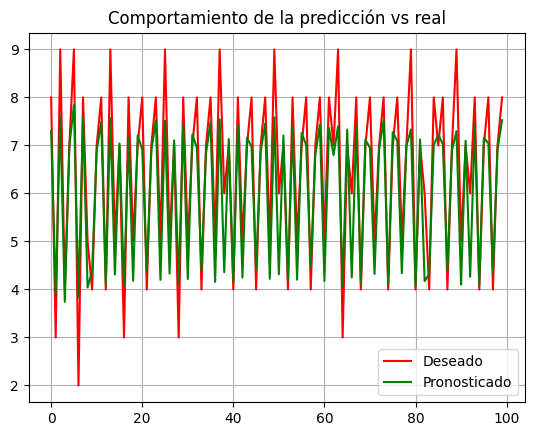

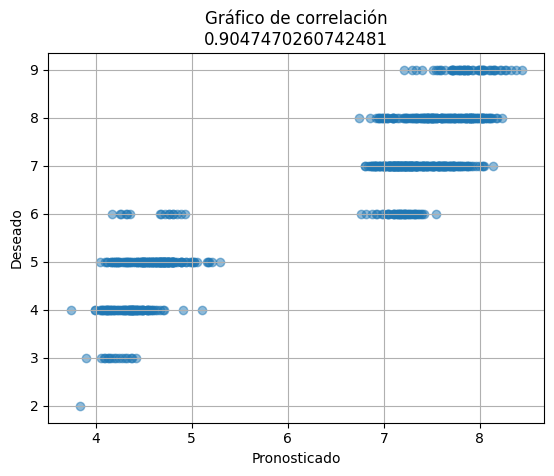

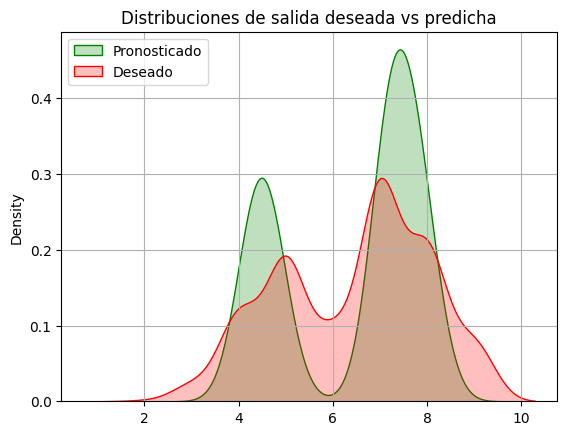

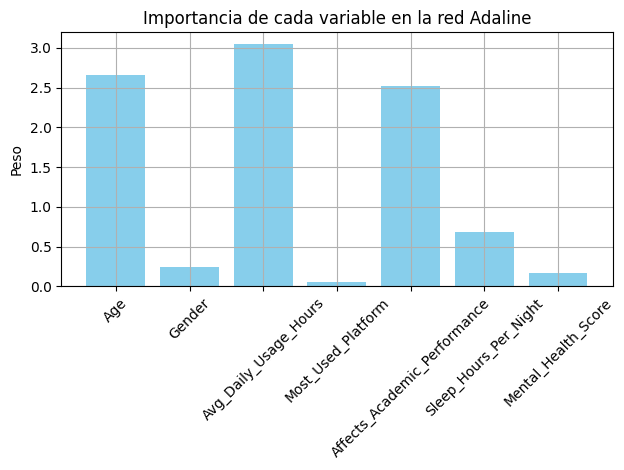

In [ ]:
adaline = tf.keras.Sequential([tf.keras.layers.Dense(units=1, input_shape=(7,), use_bias=False, activation='relu')])

adaline.compile(optimizer='sgd', loss='mse')  # mse: error cuadrático medio
adaline.summary()

# Entrenamiento
history = adaline.fit(XDn, ydn, epochs=100, verbose=0)

# Predicción
yp = adaline.predict(XDn)

# Correlación entre valores predichos y reales
dfcorr = pd.DataFrame({'yp': yp.flatten(), 'ydn': ydn})
print("Correlación entre predicción y real:\n", dfcorr.corr())

# Obtener pesos
pesos = adaline.get_weights()[0].flatten()
nombres = ['Age', 'Gender', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
           'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']

print("\nPesos aprendidos por la red:")
for nombre, peso in zip(nombres, pesos):
    print(f"{nombre:30}: {peso:.5f}")

# === Gráficas ===

# Línea Deseado vs. Pronosticado
plt.figure()
plt.plot(ydn[:100], 'r', label='Deseado')
plt.plot(yp[:100], 'g', label='Pronosticado')
plt.title("Comportamiento de la predicción vs real")
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de correlación
plt.figure()
plt.scatter(yp, ydn, alpha=0.5)
plt.grid(True)
plt.xlabel('Pronosticado')
plt.ylabel('Deseado')
plt.title('Gráfico de correlación\n' + str(dfcorr.corr().iloc[0, 1]))
plt.show()

# Gráfico de distribuciones
plt.figure()
sns.kdeplot(x=yp.flatten(), label='Pronosticado', fill=True, color='g')
sns.kdeplot(x=ydn.flatten(), label='Deseado', fill=True, color='r')
plt.title("Distribuciones de salida deseada vs predicha")
plt.grid(True)
plt.legend()
plt.show()

# Gráfico de barras de pesos
plt.figure()
plt.bar(nombres, pesos, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Peso")
plt.title("Importancia de cada variable en la red Adaline")
plt.grid(True)
plt.tight_layout()
plt.show()

**Evaluacion**

In [ ]:
# === Evaluación de múltiples entradas con Adaline ===
Xnps = [
    [20, 1, 6, 2, 1, 6, 4],  # Estudiante 1
    [22, 0, 5, 1, 0, 7, 3],  # Estudiante 2
    [19, 1, 8, 3, 1, 5, 5]   # Estudiante 3
]

# Normalizar las entradas
Xnpsn = np.array(Xnps) / np.max(XD, axis=0)
print("Datos normalizados:\n", Xnpsn)

# Predecir con Adaline
ypnps = adaline.predict(Xnpsn)

# Mostrar resultados
print("\nResultados de predicción con Adaline:")
for i, pred in enumerate(ypnps):
    score_pred = pred[0]  # Adaline ya predice en escala real (si no fue normalizada la salida)
    print(f"\nEstudiante {i+1}:")
    print(f"Score estimado de adicción: {score_pred:.2f}")

    # Interpretación del nivel de adicción
    if score_pred < 3:
        print("Nivel de adicción: Bajo (1-3)")
    elif score_pred < 7:
        print("Nivel de adicción: Moderado (4-6)")
    elif score_pred <= 10:
        print("Nivel de adicción: Alto (7-10)")
    else:
        print("Nivel de adicción: Fuera de rango esperado")


Datos normalizados:
 [[0.83333333 1.         0.70588235 0.18181818 1.         0.625
  0.44444444]
 [0.91666667 0.         0.58823529 0.09090909 0.         0.72916667
  0.33333333]
 [0.79166667 1.         0.94117647 0.27272727 1.         0.52083333
  0.55555556]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Resultados de predicción con Adaline:

Estudiante 1:
Score estimado de adicción: 7.63
Nivel de adicción: Alto (7-10)

Estudiante 2:
Score estimado de adicción: 4.78
Nivel de adicción: Moderado (4-6)

Estudiante 3:
Score estimado de adicción: 8.19
Nivel de adicción: Alto (7-10)


# Madeline

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
La correlación entre yp-ydn es:
           0         1
0  1.000000  0.584891
1  0.584891  1.000000


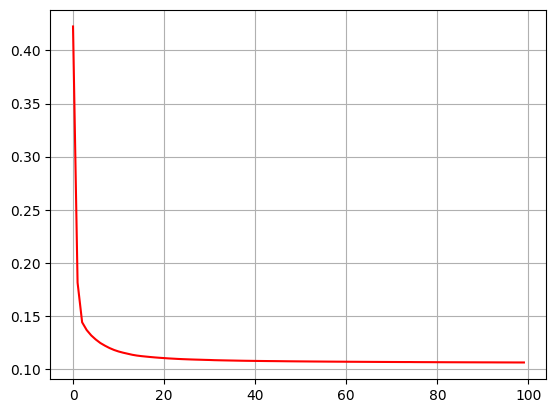

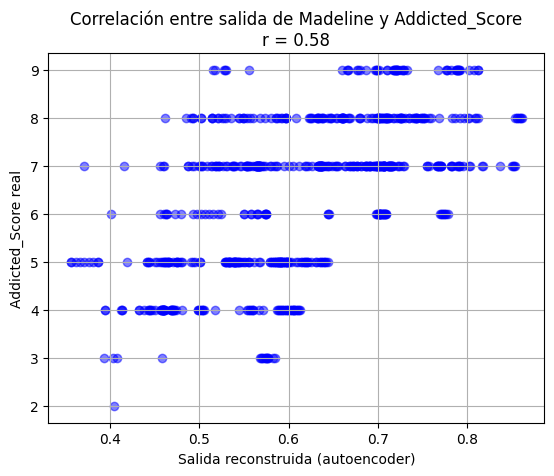

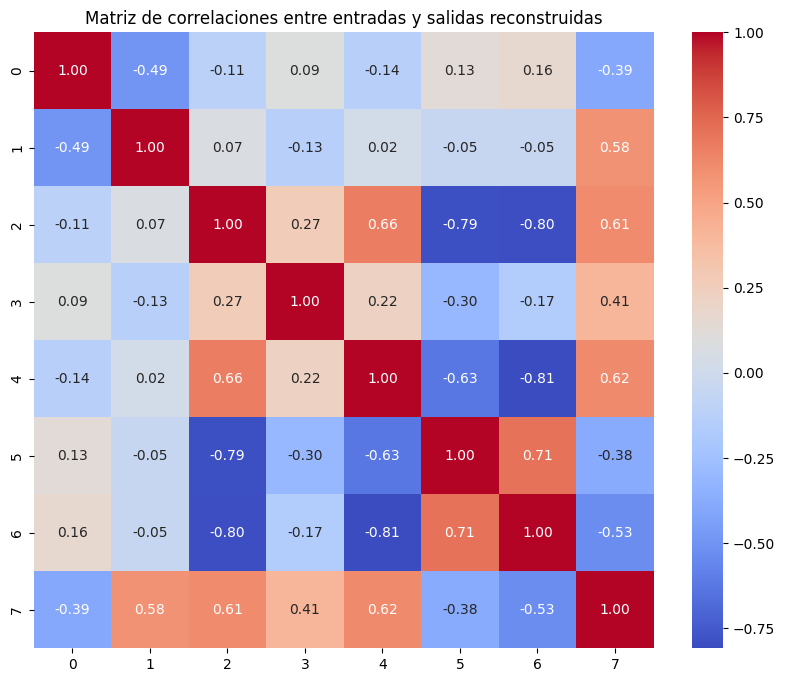

,Age,Gender,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score
0,-0.110994,0.218409,0.399988,0.25704,-0.080278,0.78175,-0.127033


In [ ]:
# Cargar los datos
nxl = '/content/drive/MyDrive/Retos/Final/Students Social Media Addiction.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0)

le_platform = LabelEncoder()

# Aplicar codificación a la columna 'Most_Used_Platform'
XDB['Most_Used_Platform'] = le_platform.fit_transform(XDB['Most_Used_Platform'])

# Puedes imprimir el mapeo para saber qué número corresponde a qué plataforma
platform_mapping = dict(zip(le_platform.classes_, le_platform.transform(le_platform.classes_)))

# Seleccionar columnas relevantes
XDB = XDB[['Age', 'Gender', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Addicted_Score']]

# Separar variables de entrada (XD) y salida (yd)
XD = np.array(XDB[['Age', 'Gender', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score',]])
yd = np.array(XDB['Addicted_Score'])

#Se procede con la normalización de las variables
XDn=XD/np.max(XD,axis=0)  #axis=0 que lo haga por columnas
ydn=yd

madaline=tf.keras.Sequential([
  tf.keras.layers.Dense(units=10,input_shape=(7,),use_bias=False, activation='relu'),
  tf.keras.layers.Dense(units=1,use_bias=False,activation='relu')])

madaline.summary()
madaline.compile(optimizer='sgd',loss='mse') #sdg: Gradiente Descenso
                                             #mse: Error Salida Modelo
history=madaline.fit(XDn,XDn,epochs=100,verbose=0)     #misma entrada: XDn - misma salida: XDn
XDnp=madaline.predict(XDn)                   #Pronóstico de la salida

df=pd.DataFrame(np.column_stack((XDn,XDnp)))
dfc=pd.DataFrame(df.corr())    #Determino las correlaciones
dfc.to_excel('correlaciones.xlsx')

#Evaluamos el modelo
yp2=madaline.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yp2,ydn)))
print("La correlación entre yp-ydn es:\n",dfcorr2.corr())

#Caida del error en el aprendizaje
ek=history.history['loss'] #Muestra el error en el aprendizaje

plt.figure()
plt.plot(ek,'r')
plt.grid(True)
plt.show()


plt.figure()
plt.scatter(yp2, ydn, alpha=0.5, color='blue')
plt.xlabel("Salida reconstruida (autoencoder)")
plt.ylabel("Addicted_Score real")
plt.title("Correlación entre salida de Madeline y Addicted_Score\nr = {:.2f}".format(dfcorr2.corr().iloc[0,1]))
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 8))
sns.heatmap(dfc, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de correlaciones entre entradas y salidas reconstruidas")
plt.show()

#Como se obtienen las ecuaciones para el modelo
WC=madaline.get_weights()
W=WC[0]; C=WC[1]
a=W@C
dfm=pd.DataFrame(a.T)
dfm.columns=['Age', 'Gender', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
           'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']
display(dfm)

**Evaluacion**

In [ ]:
# === Evaluación de múltiples entradas con Madaline ===
Xnps = [
    [20, 1, 6, 2, 1, 6, 4],  # Caso 1
    [22, 0, 5, 1, 0, 7, 3],  # Caso 2
    [19, 1, 8, 3, 1, 5, 5]   # Caso 3
]

Xnpsn = Xnps / np.max(XD, axis=0)  # Normalizar usando los máximos de entrenamiento
print("Datos normalizados:\n", Xnpsn)

ypnps = madaline.predict(Xnpsn)  # Predicción

# Mostrar resultados
print("\nResultados de predicción:")
for i, pred in enumerate(ypnps):
    score_pred = pred[0] * np.max(yd)  # Desnormalizar
    print(f"\nEstudiante {i+1}:")
    print(f"Score estimado de adicción: {score_pred:.2f}")

    # Interpretación del nivel de adicción
    if score_pred < 3:
        print("Nivel de adicción: Bajo (1-3)")
    elif score_pred < 7:
        print("Nivel de adicción: Moderado (4-6)")
    elif score_pred <= 10:
        print("Nivel de adicción: Alto (7-10)")
    else:
        print("Nivel de adicción: Fuera de rango esperado")


Datos normalizados:
 [[0.83333333 1.         0.70588235 0.18181818 1.         0.625
  0.44444444]
 [0.91666667 0.         0.58823529 0.09090909 0.         0.72916667
  0.33333333]
 [0.79166667 1.         0.94117647 0.27272727 1.         0.52083333
  0.55555556]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Resultados de predicción:

Estudiante 1:
Score estimado de adicción: 0.00
Nivel de adicción: Bajo (1-3)

Estudiante 2:
Score estimado de adicción: 0.00
Nivel de adicción: Bajo (1-3)

Estudiante 3:
Score estimado de adicción: 0.00
Nivel de adicción: Bajo (1-3)


# Modelo K-means


In [4]:
import numpy as np #Posee Funciones Matematicas
import pandas as pd #Comunicacion excel
from sklearn.metrics import accuracy_score # comparar las predicciones del modelo
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

# Cargar los datos
nxl = '/content/drive/MyDrive/Retos/Final/Students Social Media Addiction.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0)

le_platform = LabelEncoder()

# Aplicar codificación a la columna 'Most_Used_Platform'
XDB['Most_Used_Platform'] = le_platform.fit_transform(XDB['Most_Used_Platform'])

# Puedes imprimir el mapeo para saber qué número corresponde a qué plataforma
platform_mapping = dict(zip(le_platform.classes_, le_platform.transform(le_platform.classes_)))

# Seleccionar columnas relevantes
XDB = XDB[['Age', 'Gender', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Addicted_Score']]

# Separar variables de entrada (XD) y salida (yd)
XD = np.array(XDB[['Age', 'Gender', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Sleep_Hours_Per_Night',
                   'Mental_Health_Score','Addicted_Score']])
yd = np.array(XDB['Affects_Academic_Performance'])

# Entrenar el modelo
mnb = GaussianNB()
mnb.fit(XD, yd)

# Obtener información estadística del modelo
u = mnb.theta_  # Media
# print("La media de los datos es:\n", u)

varianza = mnb.var_  # Varianza
# print("La varianza de los datos es:\n", varianza)

sigma = np.sqrt(varianza)  # Desviación estándar
# print("La desviación estándar de los datos es:\n", sigma)

LS = u + sigma
LI = u - sigma
# print("El límite superior es:\n", LS)
# print("El límite inferior es:\n", LI)

# Estudiante con estas características:
XDS = [[20, 1, 6.0, 2, 5.0, 6, 1]]

ydp = mnb.predict(XDS)
print("La predicción es:", ydp)

if ydp[0] == 0:
    print("NO afecta el rendimiento académico.")
else:
    print("SÍ afecta el rendimiento académico.")

# Estudiante con estas características:
XDS2 = [[21, 1, 10, 1, 0, 8, 10]]

ydp = mnb.predict(XDS2)
print("La predicción es:", ydp)

if ydp[0] == 0:
    print("NO afecta el rendimiento académico.")
else:
    print("SÍ afecta el rendimiento académico.")




La predicción es: [0]
NO afecta el rendimiento académico.
La predicción es: [1]
SÍ afecta el rendimiento académico.


In [ ]:
from sklearn.metrics import confusion_matrix

# Predicción del modelo sobre los datos de entrada
ybp2 = mnb.predict(XD)

# Matriz de confusión
cm = confusion_matrix(yd, ybp2)
print("La matriz de confusión es:\n", cm)

# Elementos de la matriz
VN = cm[0, 0]  # Verdaderos Negativos
VP = cm[1, 1]  # Verdaderos Positivos
FN = cm[1, 0]  # Falsos Negativos
FP = cm[0, 1]  # Falsos Positivos

# Métricas de desempeño (en porcentaje)
Exactitud = (VP + VN) / (VP + VN + FP + FN) * 100
TasaError = (FP + FN) / (VP + VN + FP + FN) * 100
Sensibilidad = (VP / (VP + FN)) * 100 if (VP + FN) != 0 else 0
Especificidad = (VN / (VN + FP)) * 100 if (VN + FP) != 0 else 0
Precision = (VP / (VP + FP)) * 100 if (VP + FP) != 0 else 0
PrecisionNegativa = (VN / (VN + FN)) * 100 if (VN + FN) != 0 else 0

# Mostrar resultados redondeados
print(f"La exactitud del modelo es: {Exactitud:.2f}%")
print(f"La tasa de error del modelo es: {TasaError:.2f}%")
print(f"La sensibilidad del modelo es: {Sensibilidad:.2f}%")
print(f"La especificidad del modelo es: {Especificidad:.2f}%")
print(f"La precisión del modelo es: {Precision:.2f}%")
print(f"La precisión negativa del modelo es: {PrecisionNegativa:.2f}%")


La matriz de confusión es:
 [[249   3]
 [ 32 421]]
La exactitud del modelo es: 95.04%
La tasa de error del modelo es: 4.96%
La sensibilidad del modelo es: 92.94%
La especificidad del modelo es: 98.81%
La precisión del modelo es: 99.29%
La precisión negativa del modelo es: 88.61%


# **Analisis de Resultados**

**Analisis de Resultados Adaline**

**Desempeño del Modelo Adaline**
La evaluación del modelo Adaline reveló una correlación de 0.904747 entre los valores predichos y los valores reales de la variable Addicted Score. Esta correlación es alta y cercano a 1, por lo que se demuestra la notable capacidad predictiva del modelo. En términos prácticos, esto significa que las estimaciones del modelo siguen de cerca las puntuaciones reales de adicción de los estudiantes, lo que lo posiciona como una herramienta fiable para la identificación de individuos en riesgo.

Visualmente, esto se traduce en una superposición casi total de las curvas de distribución de los valores deseados y pronosticados, y una concentración densa de puntos alrededor de la línea de identidad en el diagrama de dispersión.

**Pesos de las Variables**
Un aspecto crucial de este análisis radica en la interpretación de los pesos asignados por el modelo a cada variable de entrada. Estos pesos no solo indican la dirección de la relación, sino que su magnitud (en valor absoluto) revela la importancia relativa de cada factor en la determinación del nivel de adicción.

Horas de Uso Diario (Avg_Daily_Usage_Hours): Con un peso de 3.04369, esta variable emerge como el predictor más potente del nivel de adicción. El tiempo que un estudiante dedica diariamente a las redes sociales es, sin duda, el factor más determinante.

Edad (Age): Con un peso de 2.65486, la edad se posiciona como el segundo factor más influyente. Esto sugiere que la susceptibilidad a la adicción, o los patrones de uso que conducen a ella, pueden variar significativamente en función del grupo etario del estudiante.

Afectación del Rendimiento Académico (Affects_Academic_Performance): Con un peso de 2.52100, esta variable es el tercer predictor más relevante. La percepción por parte del estudiante de que el uso de redes sociales impacta negativamente su desempeño académico es un fuerte indicador de un nivel de adicción elevado, actuando como una señal de alerta temprana.

Horas de Sueño por Noche (Sleep_Hours_Per_Night): Con un peso de 0.67743, se observa una influencia moderada. Este hallazgo sugiere una conexión entre los patrones de sueño y la adicción, posiblemente debido al uso de dispositivos electrónicos durante horas nocturnas que comprometen el descanso.

Género (Gender) y Puntuación de Salud Mental (Mental_Health_Score): Con pesos de 0.23977 y 0.17195, respectivamente, estas variables muestran una influencia relativamente menor en la predicción directa de la adicción en este modelo lineal. Si bien son aspectos fundamentales del bienestar estudiantil, su relación directa y lineal con el Addicted_Score parece ser menos pronunciada que la de los factores anteriores.

Plataforma Más Usada (Most_Used_Platform): Con un peso de 0.04870, esta variable presenta una influencia mínima. Este resultado es significativo, ya que indica que la adicción no está intrínsecamente ligada a una plataforma social específica, sino más bien al comportamiento general de uso de las redes sociales.

**Para comprobar la aplicación del modelo, se evaluaron tres perfiles de estudiantes:**

Estudiante 1 (Puntuación estimada: 7.63 – Nivel de Adicción: Alto): Este estudiante presenta un uso diario de 6 horas y percibe un impacto negativo en su rendimiento académico. La combinación de un uso considerable y la afectación académica, en línea con los pesos del modelo, justifica su clasificación en un nivel de adicción alto.

Estudiante 2 (Puntuación estimada: 4.78 – Nivel de Adicción: Moderado): A pesar de una edad similar, este estudiante reporta un menor uso diario (5 horas) y, crucialmente, no percibe un impacto en su rendimiento académico. Estos factores, especialmente la ausencia de afectación académica, conducen a una predicción de adicción moderada.

Estudiante 3 (Puntuación estimada: 8.19 – Nivel de Adicción: Alto): Con 8 horas de uso diario de redes sociales y un impacto percibido en el rendimiento académico, este perfil exhibe la combinación de factores de riesgo más elevada, lo que se refleja en la puntuación de adicción más alta pronosticada por el modelo.

**Analisis de Resultados Madaline**

Se prestesnta una correlación de 0.58, aunque no tan alta como la obtenida con Adaline (0.90), pero es un valor moderado y significativo. Dado que Madeline es un autoencoder cuyo objetivo principal es la reconstrucción de los datos de entrada, y no directamente la predicción del Addicted_Score, esta correlación indica que la representación latente o "reconstrucción" que hace Madeline retiene una parte importante de la información relacionada con el nivel de adicción. Esto sugiere que las características aprendidas por el autoencoder son relevantes para la variable objetivo, aunque no esté optimizado explícitamente para predecirla. La dispersión de los puntos, aunque con una tendencia positiva, es más amplia que la observada con Adaline.

La tabla de los pesos muestra una combinación de pesos resultante de la multiplicación de las matrices de pesos W y C del modelo Madeline, que tiene dos capas densas.

Age: -0.110994

Gender: 0.218409

Avg_Daily_Usage_Hours: 0.399988

Most_Used_Platform: 0.25704

Affects_Academic_Performance: -0.080278

Sleep_Hours_Per_Night: 0.78175

Mental_Health_Score: -0.127033

A diferencia del modelo Adaline, donde los pesos indican una influencia directa en la predicción, en Madeline estos pesos representan la contribución de las variables de entrada a las características latentes que luego se utilizan para reconstruir las salidas. Interpretar directamente estos pesos individuales como "importancia" en el mismo sentido que en Adaline es más complejo, ya que la red tiene una capa oculta. Sin embargo, los valores absolutos más altos (como Sleep_Hours_Per_Night y Avg_Daily_Usage_Hours) sugieren que estas variables son cruciales para la representación interna que Madeline construye. El hecho de que "Avg_Daily_Usage_Hours" siga siendo relevante aquí (0.399988) es consistente con su importancia en el modelo Adaline. "Sleep_Hours_Per_Night" emerge con un peso particularmente alto (0.78175), lo que podría indicar que esta variable es fundamental para la forma en que Madeline codifica y decodifica la información sobre los estudiantes.



**Analisis de Resultados Naive Bayes**

Se utilizó el modelo Naive Bayes Gaussiano para predecir si el uso de redes sociales afecta o no el rendimiento académico de los estudiantes. La variable objetivo fue Affects_Academic_Performance (0 = No afecta, 1 = Sí afecta), mientras que como variables explicativas se utilizaron características personales y de comportamiento como edad, género, horas de uso, plataforma más usada, horas de sueño, salud mental y nivel de adicción.

El modelo fue entrenado con los datos completos y luego evaluado mediante una matriz de confusión y varias métricas de desempeño clave. Los resultados fueron los siguientes:

Verdaderos Negativos (VN = 249): El modelo predijo correctamente que 249 estudiantes no son afectados en su rendimiento académico.
Falsos Positivos (FP = 3): El modelo predijo incorrectamente que 3 estudiantes sí son afectados, cuando en realidad no lo son.
Falsos Negativos (FN = 32): El modelo predijo incorrectamente que 32 estudiantes no son afectados, cuando en realidad sí lo son. Este es un error importante si el objetivo es identificar a los estudiantes en riesgo.
Verdaderos Positivos (VP = 421): El modelo predijo correctamente que 421 estudiantes sí son afectados en su rendimiento académico.

Exactitud (Accuracy): 95.04% - Esto me Indica que el modelo acierta en más del 95% de los casos.

Tasa de error: 4.96% - Solo se tiene un pequeño porcentaje fue clasificado incorrectamente.


Sensibilidad del 92.94%: El modelo identificó correctamente al 93% arpoximadamente. y esto me indica que es un excelente desempeño para evitar falsos negativos.

Especificidad de 98.81%: De todos los que dijeron que no se ven afectados, casi el 99% fue correctamente clasificado.

Precisión del 99.29%: Entre todos los casos que el modelo predijo como “sí afecta”, casi todos realmente eran positivos. Esto indica alta confiabilidad cuando el modelo alerta un impacto académico.

Precisión negativa del 88.61%: Cuando el modelo predice que no hay afectación, tiene un poco más de probabilidad de equivocarse, aunque sigue siendo aceptable.

Este modelo Gaussian Naive Bayes demostró ser altamente efectivo para clasificar el impacto del uso de redes sociales sobre el rendimiento académico. Gracias a su alta precisión, especificidad y sensibilidad, puede ser utilizado como herramienta de apoyo para identificar estudiantes en riesgo de bajo rendimiento académico derivado de malos hábitos digitales o problemas de salud mental.




**Conclusion**

Los resultados obtenidos a través del uso de los modelos Adaline, Madeline y Naive Bayes permiten establecer un panorama integral sobre cómo distintos factores personales y conductuales influyen en el nivel de adicción a redes sociales y su impacto en el rendimiento académico de los estudiantes.

El modelo Adaline demuestra una alta capacidad predictiva para estimar el nivel de adicción, permitiendo identificar con precisión a los estudiantes con mayor riesgo. Esto puede ser de gran valor para programas de prevención, al ofrecer una herramienta basada en datos para detectar patrones de comportamiento problemático antes de que se traduzcan en consecuencias académicas o psicológicas.

El modelo Madeline, por su parte, permite explorar representaciones latentes de los datos, útiles para tareas de segmentación o agrupamiento. Esto podría servir a las organizaciones para diseñar intervenciones personalizadas, agrupando a los estudiantes por perfiles de uso, calidad de sueño, o salud mental, y adaptando estrategias según cada grupo identificado.

Finalmente, el modelo Naive Bayes permite predecir directamente si el uso de redes sociales afecta el rendimiento académico, con una exactitud superior al 95%. Esto lo convierte en una herramienta eficaz para implementar alertas tempranas en plataformas educativas o sistemas de monitoreo académico. Por ejemplo, instituciones educativas podrían integrar un sistema automatizado que identifique a los estudiantes en riesgo de bajo desempeño debido a sus hábitos digitales.

En conjunto, estos modelos ofrecen a las organizaciones educativas una base sólida para la toma de decisiones informadas, el diseño de estrategias preventivas, y la implementación de programas de bienestar digital. Adoptar este tipo de analítica no solo permite detectar problemas, sino también promover una cultura de salud mental y uso responsable de la tecnología entre los jóvenes.